# 05 · Logistic Regression – Baseline Direction Classifier

Use a **Logistic Regression** GLM as the baseline binary classifier and evaluate with standard classification metrics and a confusion matrix.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              RocCurveDisplay, classification_report)

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Load Data & Split

In [ ]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)

FEATURES = ['MA_cross', 'Volatility', 'RSI', 'BB_width', 'BB_pct', 'LogReturn']
X = df[FEATURES].values
y = df[config.TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE,
    shuffle=False,           # keep temporal order
    random_state=config.RANDOM_STATE,
)
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')

Train: (3114, 6)   Test: (779, 6)


## 2. Scale & Fit

In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=config.RANDOM_STATE)
lr.fit(X_train_sc, y_train)
print('Logistic Regression fitted ✓')

Logistic Regression fitted ✓


## 3. Predictions & Metrics

In [4]:
y_pred      = lr.predict(X_test_sc)
y_prob      = lr.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1       : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Up (1)']))

Accuracy : 0.5006
Precision: 0.5308
Recall   : 0.5012
F1       : 0.5156
ROC-AUC  : 0.5063

              precision    recall  f1-score   support

    Down (0)       0.47      0.50      0.48       366
      Up (1)       0.53      0.50      0.52       413

    accuracy                           0.50       779
   macro avg       0.50      0.50      0.50       779
weighted avg       0.50      0.50      0.50       779



## 4. Confusion Matrix

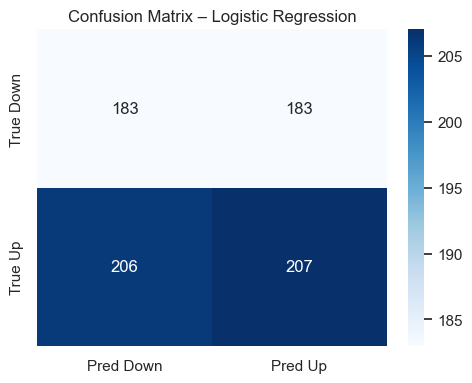

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Down', 'Pred Up'],
            yticklabels=['True Down', 'True Up'], ax=ax)
ax.set_title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

## 5. ROC Curve

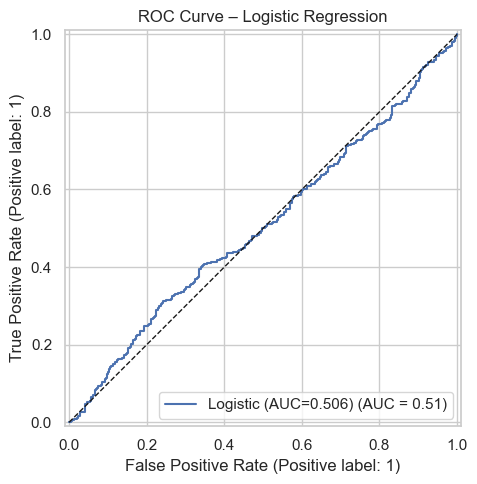

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                  name=f'Logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC Curve – Logistic Regression')
plt.tight_layout()
plt.show()

## 6. Coefficient Inspection

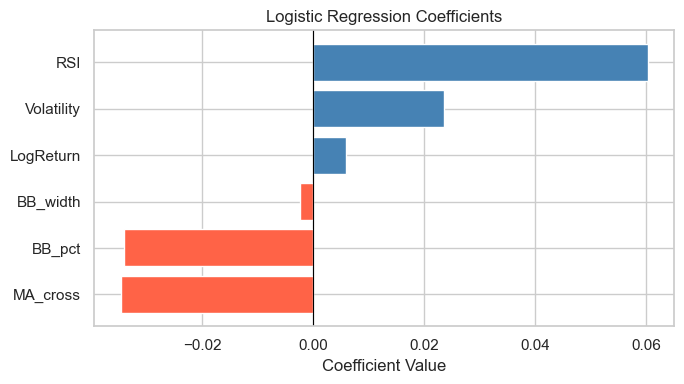

In [7]:
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()